In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [4]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [5]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [6]:
rate_col = "Liver Rate"

In [7]:
design_matrix_otrain[rate_col].mean()

0.1442676470588235

In [8]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

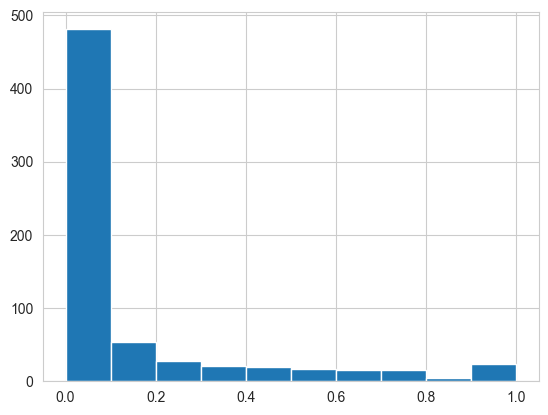

In [9]:
design_matrix_train[rate_col].hist(bins=10)

In [10]:
design_matrix_train['group'].value_counts()

group
1    491
2    189
Name: count, dtype: int64

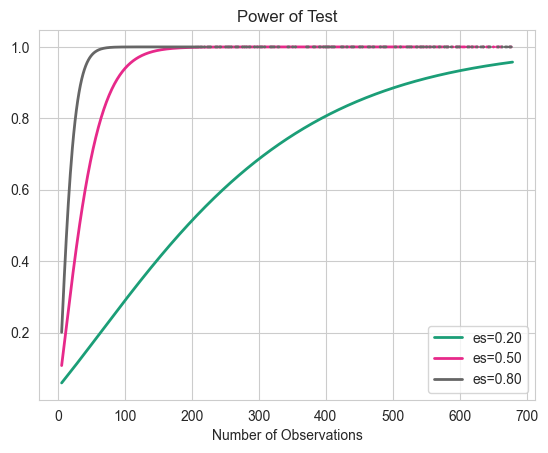

In [11]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [12]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [13]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [14]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [15]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

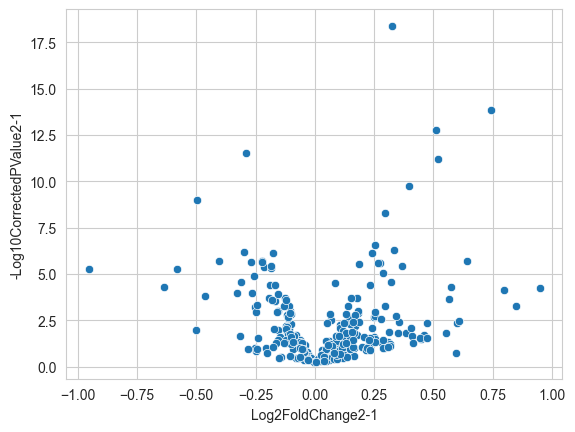

In [16]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [17]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
72,Q15582,BGH3_HUMAN,1.056757,12.223064,11.897579,0.485489,0.342137,0.325485,2.650846e-21,189,...,12.189729,12.181741,11.650090,12.185936,12.036681,10.988674,11.564865,12.850858,11.887155,12.531832
154,P01033,TIMP1_HUMAN,1.091077,10.865983,10.124123,1.198632,0.949797,0.741860,1.884505e-16,189,...,11.305144,9.690175,10.005689,11.112195,9.291888,10.080163,9.175368,10.305271,10.987082,9.923244
183,P05362,ICAM1_HUMAN,0.883187,10.051380,9.542204,0.906971,0.659637,0.509176,3.409601e-15,189,...,9.423490,9.542654,9.365688,10.190797,9.319579,9.293526,9.317505,9.946124,9.173564,10.092941
62,P05546,HEP2_HUMAN,0.705333,15.802456,16.091984,0.500461,0.418278,-0.289527,7.999606e-14,189,...,14.888242,16.497491,15.668729,15.408852,16.443323,16.398452,16.243979,16.422207,15.971221,16.532829
162,P01833,PIGR_HUMAN,0.823127,11.612349,11.094478,0.986240,0.722821,0.517871,1.914542e-13,189,...,10.815594,10.893127,10.640803,11.654822,11.584860,11.376154,9.675695,11.884602,10.664987,12.582187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,P14618,KPYM_HUMAN,0.016788,9.459024,9.443158,1.555633,1.548899,0.015866,9.050377e-01,189,...,10.363718,9.968115,10.410554,12.258466,9.971399,9.858899,9.309232,10.311892,10.125613,10.481829
275,P07477,TRY1_HUMAN,0.004492,14.601181,14.597094,0.668108,0.600705,0.004087,9.387545e-01,189,...,14.437476,14.946164,14.013308,14.461313,15.017907,14.680294,14.936390,14.885729,13.464894,14.594135
157,P05090,APOD_HUMAN,0.003323,15.710423,15.713368,0.488765,0.488503,-0.002945,9.439630e-01,189,...,16.175349,15.810826,15.879311,16.941369,15.351709,15.633920,15.631861,16.110138,16.031145,14.966750
50,O75882,ATRN_HUMAN,0.001965,12.739877,12.741552,0.378269,0.384680,-0.001675,9.593104e-01,189,...,12.664795,13.356835,12.706596,13.720446,13.169148,12.609911,13.372958,12.760914,13.008290,12.522964


In [18]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [19]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [20]:
protein_columns = training_data.columns.to_list()

In [21]:
len(protein_columns)

287

In [22]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [24]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.6613756613756614,
 0.6171574441243047,
 0.7911582394448559,
 0.7512512004319576,
 0.8406174713222446)

In [25]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [26]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [27]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
PDLI1_HUMAN,0.708747,0.771572,0.605035,0.695118
TBB5_HUMAN,0.696788,0.911380,0.365334,0.657834
PZP_HUMAN,0.590047,0.688837,0.594121,0.624335
ITA2B_HUMAN,0.680726,0.642453,0.539943,0.621041
BGH3_HUMAN,0.561808,0.808414,0.449643,0.606622
...,...,...,...,...
COL10_HUMAN,0.043516,0.071175,0.010578,0.041756
PRG2_HUMAN,0.006444,0.003338,0.111874,0.040552
A1BG_HUMAN,0.019125,0.053772,0.036187,0.036362


In [28]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [29]:
import colorcet as cc

In [30]:
colormap = cc.glasbey_cool

In [31]:
color = colormap[1]

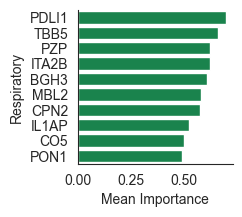

In [32]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [33]:
feature_importance_results["Panel"] = "Liver"

In [34]:
feature_importance_results.to_csv(
    "liver_importance.tsv",
    sep="\t",
    index=False
)

In [35]:
from joblib import dump


with open("models/liver_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/liver_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
